In [6]:
from nba_api.stats.endpoints import shotchartdetail
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [51]:
from matplotlib.patches import Circle, Rectangle, Arc

def draw_court(ax, color="white", lw=1.5):
    # Hoop
    ax.add_patch(Circle((0, 0), 7.5, linewidth=lw, color=color, fill=False))

    # Backboard
    ax.add_patch(Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color))

    # Paint
    ax.add_patch(Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False))
    ax.add_patch(Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False))

    # Free throw arc
    ax.add_patch(Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color))
    ax.add_patch(Arc((0, 142.5), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color))

    # Restricted area
    ax.add_patch(Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color))

    # Corner 3
    ax.add_patch(Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color))
    ax.add_patch(Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color))

    # 3PT arc
    ax.add_patch(Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color))

    # Center arc (top of half court)
    ax.add_patch(Arc((0, 422.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color))

In [2]:

shot_data = shotchartdetail.ShotChartDetail(
    player_id=0,
    team_id=0,
    season_type_all_star='Playoffs',
    season_nullable='2025-26',
    context_measure_simple='FGA',
)
df = shot_data.get_data_frames()[0]

made = df[df['SHOT_MADE_FLAG'] == 1]
missed = df[df['SHOT_MADE_FLAG'] == 0]


In [3]:
print(df["SHOT_ZONE_RANGE"].dropna().unique())

['Less Than 8 ft.' '24+ ft.' '8-16 ft.' '16-24 ft.' 'Back Court Shot']


In [ ]:
!pip install plotly.express

In [10]:
df

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
0,Shot Chart Detail,0042500101,7,1630595,Cade Cunningham,1610612765,Detroit Pistons,1,11,41,Missed Shot,Driving Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,2,0,28,1,0,20260419,DET,ORL
1,Shot Chart Detail,0042500101,9,1631094,Paolo Banchero,1610612753,Orlando Magic,1,11,32,Missed Shot,Driving Layup Shot,2PT Field Goal,In The Paint (Non-RA),Center(C),Less Than 8 ft.,4,-4,42,1,0,20260419,DET,ORL
2,Shot Chart Detail,0042500101,13,1630591,Jalen Suggs,1610612753,Orlando Magic,1,11,19,Made Shot,Jump Shot,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,25,-179,177,1,1,20260419,DET,ORL
3,Shot Chart Detail,0042500101,18,1629130,Duncan Robinson,1610612765,Detroit Pistons,1,10,55,Made Shot,Jump Shot,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,25,140,216,1,1,20260419,DET,ORL
4,Shot Chart Detail,0042500101,20,1630591,Jalen Suggs,1610612753,Orlando Magic,1,10,34,Made Shot,Jump Shot,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,26,131,227,1,1,20260419,DET,ORL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8137,Shot Chart Detail,0042500176,681,1642261,Dalton Knecht,1610612747,Los Angeles Lakers,4,1,5,Missed Shot,Jump Shot,3PT Field Goal,Above the Break 3,Center(C),24+ ft.,26,-47,260,1,0,20260501,HOU,LAL
8138,Shot Chart Detail,0042500176,684,1628988,Aaron Holiday,1610612745,Houston Rockets,4,0,50,Made Shot,Driving Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,1,15,6,1,1,20260501,HOU,LAL
8139,Shot Chart Detail,0042500176,686,1641733,Nick Smith Jr.,1610612747,Los Angeles Lakers,4,0,29,Missed Shot,Jump Shot,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,27,-197,195,1,0,20260501,HOU,LAL
8140,Shot Chart Detail,0042500176,688,1630256,Jae'Sean Tate,1610612745,Houston Rockets,4,0,23,Missed Shot,Running Pull-Up Jump Shot,3PT Field Goal,Above the Break 3,Center(C),24+ ft.,25,-66,245,1,0,20260501,HOU,LAL


In [12]:
df['ACTION_TYPE'].value_counts()

ACTION_TYPE
Jump Shot                             2144
Pullup Jump shot                      1176
Driving Layup Shot                     731
Driving Floating Jump Shot             514
Step Back Jump shot                    450
Running Layup Shot                     274
Driving Finger Roll Layup Shot         232
Running Jump Shot                      220
Fadeaway Jump Shot                     217
Cutting Layup Shot                     180
Turnaround Fadeaway shot               174
Tip Layup Shot                         171
Running Pull-Up Jump Shot              143
Turnaround Jump Shot                   139
Putback Layup Shot                     132
Running Dunk Shot                      119
Driving Floating Bank Jump Shot        117
Cutting Dunk Shot                      111
Driving Dunk Shot                      104
Floating Jump shot                      81
Alley Oop Dunk Shot                     77
Driving Hook Shot                       72
Turnaround Hook Shot                    70

In [54]:
made = df[df['SHOT_MADE_FLAG'] == 1]
missed = df[df['SHOT_MADE_FLAG'] == 0]

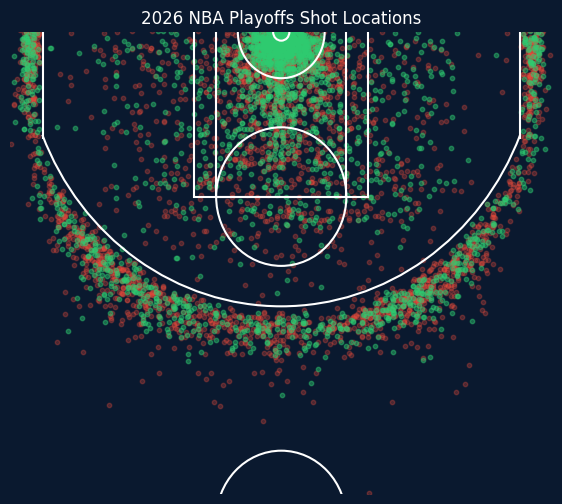

In [55]:
fig, ax = plt.subplots(figsize=(7, 6))

fig.patch.set_facecolor("#0A192F")   # whole background
ax.set_facecolor("#0A192F")          # plot area
ax.scatter(missed['LOC_X'], missed['LOC_Y'], color = "#e74c3c", s=10, alpha=0.3)
ax.scatter(made['LOC_X'], made['LOC_Y'], color = "#2ecc71", s=10, alpha=0.45)
plt.title('2026 NBA Playoffs Shot Locations')
plt.xlabel('Court X')
plt.ylabel('Court Y')
draw_court(ax, color="white")
ax.set_xlim(-250, 250)
ax.set_ylim(0, 400)
ax.invert_yaxis()
plt.axis("off")
plt.show()